In [1]:
# Library
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

### Polymarket EDA for Crypto

**Table of Contents**

1. Environment Setup, Data Loading, and Preprocessing

2. Election Event Analysis by Country

3. Testing Multiple Similar Events

### Part 1

In [2]:
# Run EDA starter as the base
%run eda_starter_template.py


[Memory] Initial memory usage: 193.22 MB

Loading Bitcoin data from D:\Heran Du\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\lse-bitcoin-analytics-capstone-template\data\Coin Metrics\coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 193.22 MB
[Memory] After loading Bitcoin data: 196.20 MB (Δ 2.98 MB)
Error loading Bitcoin data: 系统找不到指定的文件。 (os error 2): ...ct Bitcoin/lse-bitcoin-analytics-capstone-template/data/Coin Metrics/coinmetrics_btc.csv (set POLARS_VERBOSE=1 to see full path)
Loading Polymarket data from D:\Heran Du\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\lse-bitcoin-analytics-capstone-template\data\Polymarket...
[Memory] Before loading Polymarket data: 196.21 MB
[Memory] After loading Polymarket data: 196.21 MB (Δ 0.00 MB)

[Memory] Final memory usage: 196.21 MB (Total Δ: 2.99 MB)

EDA Layout Complete. Check the 'plots' directory for visualizations.


In [12]:
# Download data
%run "D:/Heran Du/Study material/The London School of Economics and Politics/ST498 Capstone Project Bitcoin/lse-bitcoin-analytics-capstone-template/data/download_data.py"

--- Downloading Capstone Data ---


Retrieving folder contents


Retrieving folder 1SvAwcdegMzgPANM4pnuTH_9DbNEyXt8N BRK Metrics
Processing file 1wtH8dGFqvNco3OcSd5V0sdfJ_NGmiOdB brk_metrics.parquet
Processing file 1PKEehgLbJtSfFsUa3awLLuCkEWfdWF8K brk-metrics-parquet-schema.md
Retrieving folder 1mgd1yrowPdQ0JKtdnKBQYHpvcdyRlXcV Coin Metrics
Processing file 1IUADRKckAZVoFYIJjTt9f_la-CQmnXIN coinmetrics_btc.csv
Processing file 1KVBZIl45-DnY0EzbA6-qFZi7kvu1iH8H coinmetrics_spec.md
Retrieving folder 1f_RjuR2AVTpuJeX6jgeoKcspjUp9_lif Polymarket
Processing file 14v0AUTMO6GwQ4ItLNRI8EuxLXplvCoGt finance_politics_event_stats.parquet
Processing file 1oF4B2zvi21br9a6NFVTwjAB8mfNuLdYx finance_politics_markets.parquet
Processing file 1z4nfPZL04Rkhp82piCvqRFerKBQbrXCh finance_politics_odds_history.parquet
Processing file 1QrWoxsFnfxv7Qs1lR4j2wpTs20MqOLnk finance_politics_summary.parquet
Processing file 1K1DjGkN4fkDMRXqZekS_-vRn-WErRLsz finance_politics_tokens.parquet
Processing file 1GO00RPaS7Q2ncX0fcUHiBLyy4bZR4_Yt finance_politics_trades.parquet
Processing fi

Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From (original): https://drive.google.com/uc?id=1wtH8dGFqvNco3OcSd5V0sdfJ_NGmiOdB
From (redirected): https://drive.google.com/uc?id=1wtH8dGFqvNco3OcSd5V0sdfJ_NGmiOdB&confirm=t&uuid=1a11fcfd-8d48-4197-9f6c-f7a94301f5fc
To: d:\Heran Du\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\lse-bitcoin-analytics-capstone-template\eda\tmp_capstone_data\BRK Metrics\brk_metrics.parquet
100%|██████████| 1.16G/1.16G [01:04<00:00, 17.9MB/s]
Downloading...
From: https://drive.google.com/uc?id=1PKEehgLbJtSfFsUa3awLLuCkEWfdWF8K
To: d:\Heran Du\Study material\The London School of Economics and Politics\ST498 Capstone Project Bitcoin\lse-bitcoin-analytics-capstone-template\eda\tmp_capstone_data\BRK Metrics\brk-metrics-parquet-schema.md
100%|██████████| 9.50k/9.50k [00:00<00:00, 4.62MB/s]
Downloading...
From: https://drive.google.com/uc?id=1IUADRKc

Organizing files...
  Keeping: BRK Metrics\brk-metrics-parquet-schema.md
  Keeping: BRK Metrics\brk_metrics.parquet
  Keeping: Coin Metrics\coinmetrics_btc.csv
  Keeping: Coin Metrics\coinmetrics_spec.md
  Keeping: Polymarket\finance_politics_event_stats.parquet
  Keeping: Polymarket\finance_politics_markets.parquet
  Keeping: Polymarket\finance_politics_odds_history.parquet
  Keeping: Polymarket\finance_politics_summary.parquet
  Keeping: Polymarket\finance_politics_tokens.parquet
  Keeping: Polymarket\finance_politics_trades.parquet
  Keeping: Polymarket\polymarket_btc_analytics_schema.md

Successfully organized 11 file(s).
--- Finished downloading ---

Data download and organization complete.



Download completed


In [3]:
# Path variables
COINMETRICS_PATH = "D:/Heran Du/Study material/The London School of Economics and Politics/ST498 Capstone Project Bitcoin/lse-bitcoin-analytics-capstone-template/eda/data/Coin Metrics/coinmetrics_btc.csv"
POLYMARKET_DIR = "D:/Heran Du/Study material/The London School of Economics and Politics/ST498 Capstone Project Bitcoin/lse-bitcoin-analytics-capstone-template/eda/data/Polymarket"

In [4]:
# Load CoinMetric data and Polymarket data
btc_df = load_bitcoin_data(COINMETRICS_PATH)

poly_data = {}

for name, f in [('markets', 'finance_politics_markets.parquet'),
                ('odds_history', 'finance_politics_odds_history.parquet'),
                ('summary', 'finance_politics_summary.parquet'),
                ('tokens', 'finance_politics_tokens.parquet'),
                ('event_stats', 'finance_politics_event_stats.parquet')]:
    try:
        poly_data[name] = pd.read_parquet(os.path.join(POLYMARKET_DIR, f))
        print(f"✓ {name}: {len(poly_data[name]):,}")
    except Exception as e:
        print(f"⚠ {name}: skipped")
        print(type(e).__name__, e)


Loading Bitcoin data from D:/Heran Du/Study material/The London School of Economics and Politics/ST498 Capstone Project Bitcoin/lse-bitcoin-analytics-capstone-template/eda/data/Coin Metrics/coinmetrics_btc.csv...
[Memory] Before loading Bitcoin data: 196.37 MB
[Memory] After loading Bitcoin data: 205.13 MB (Δ 8.76 MB)
Successfully loaded 6221 rows.
✓ markets: 78,321
✓ odds_history: 2,143,181
✓ summary: 78,321
✓ tokens: 156,636
✓ event_stats: 44,033


In [5]:
# Check the categories of Polymarket data
category = poly_data['markets'].groupby('category')
print(category.groups.keys())
category.size()

dict_keys(['', 'Business', 'Coronavirus', 'Coronavirus-', 'Crypto', 'Global Politics', 'Politics', 'Pop-Culture ', 'Tech', 'US-current-affairs', 'Ukraine & Russia'])


category
                      77516
Business                113
Coronavirus               3
Coronavirus-              1
Crypto                  340
Global Politics          56
Politics                  1
Pop-Culture               4
Tech                      2
US-current-affairs      265
Ukraine & Russia         20
dtype: int64

In [6]:
# 1. Define your keyword map
keyword_map = {
    'Crypto': 'bitcoin|eth|solana|crypto|token|airdrop',
    'Politics': 'trump|biden|harris|election|senate|republican|democrat',
    'Ukraine & Russia': 'ukraine|russia|putin|zelensky|kremlin',
    'Pop-Culture': 'oscars|grammy|taylor swift|box office|celebrity',
    'Tech': 'ai|openai|gpt|google|nvidia|meta|apple',
    'Global Politics': 'israel|gaza|iran|china|taiwan|uk|london'
}

# 2. Filter for only the rows where category is blank
blank_mask = (poly_data['markets']['category'] == '') | (poly_data['markets']['category'].isna())

# 3. Loop through the map and update blank categories based on question text
for cat, keywords in keyword_map.items():
    # Only update if the row is currently blank AND the question contains a keyword
    match_mask = blank_mask & poly_data['markets']['question'].str.contains(keywords, case=False, na=False)
    poly_data['markets'].loc[match_mask, 'category'] = cat

# 4. See how many are left blank now
print(poly_data['markets']['category'].value_counts())

category
Crypto                57852
Politics              10909
                       7421
Tech                    766
Global Politics         694
Ukraine & Russia        293
US-current-affairs      265
Business                113
Pop-Culture               4
Coronavirus               3
Coronavirus-              1
Name: count, dtype: int64


In [7]:
import duckdb

trades_path = os.path.join(POLYMARKET_DIR, "finance_politics_trades.parquet")

needed_categories = ["Politics", "Ukraine & Russia", "Global Politics"]

needed_market_ids = (
    poly_data["markets"]
    .loc[poly_data["markets"]["category"].isin(needed_categories), ["market_id"]]
    .dropna()
    .drop_duplicates()
)

con = duckdb.connect()
con.register("needed_market_ids", needed_market_ids)

trades_df = con.execute("""
    SELECT 
        t.trade_id,
        t.market_id,
        t.timestamp,
        t.price,
        t.size,
        t.side
    FROM read_parquet(?) AS t
    INNER JOIN needed_market_ids AS m
        ON t.market_id = m.market_id
""", [trades_path]).df()

print(f"✓ filtered trades: {len(trades_df):,}")


✓ filtered trades: 2,762,758


In [8]:
# Separate Polymarket data into different data frames
markets_df = poly_data['markets'].copy()
event_stats_df = poly_data['event_stats'].copy()
odds_history_df = poly_data['odds_history'].copy()
summary_df = poly_data['summary'].copy()
tokens_df = poly_data['tokens'].copy()

In [9]:
# Fix timestamp unit mismatch for trades_df

if pd.api.types.is_datetime64_any_dtype(trades_df["timestamp"]):
    
    # Check if timestamps were incorrectly parsed as 1970
    if trades_df["timestamp"].dt.year.eq(1970).all():
        
        trades_df["timestamp"] = pd.to_datetime(
            trades_df["timestamp"].astype("int64"),
            unit="ms",
            errors="coerce"
        )

else:
    
    # If timestamp is numeric
    trades_df["timestamp"] = pd.to_datetime(
        trades_df["timestamp"],
        unit="ms",
        errors="coerce"
    )

# Fix timestamp unit mismatch for odds_history_df

if pd.api.types.is_datetime64_any_dtype(odds_history_df["timestamp"]):
    
    if odds_history_df["timestamp"].dt.year.eq(1970).all():
        
        odds_history_df["timestamp"] = pd.to_datetime(
            odds_history_df["timestamp"].astype("int64"),
            unit="ms",
            errors="coerce"
        )

else:
    
    odds_history_df["timestamp"] = pd.to_datetime(
        odds_history_df["timestamp"],
        unit="ms",
        errors="coerce"
    )

In [10]:
# Create date column for merging with BTC data
trades_df["date"] = trades_df["timestamp"].dt.date
odds_history_df["date"] = odds_history_df["timestamp"].dt.date

btc_df = btc_df.to_pandas()

btc_df["time"] = pd.to_datetime(btc_df["time"])

btc_df["log_return"] = np.log(btc_df["PriceUSD"]).diff()

btc_df["date"] = btc_df["time"].dt.date

In [11]:
# Filter markets that are categorized as politics

election_markets = markets_df[
    markets_df['category'] == 'Politics'
].copy()

print("Number of election markets:", len(election_markets))

election_markets[['market_id','question']].head()

Number of election markets: 10909


,market_id,question
32,248442,Will @realDonaldTrump tweet by April 1?
33,248444,Will Donald Trump be President of the USA on M...
34,248451,Will Joe Biden be President of the United Stat...
36,248480,Will Lori Lightfoot win the 2023 Chicago Mayor...
37,248481,Will Paul Vallas win the 2023 Chicago Mayoral ...


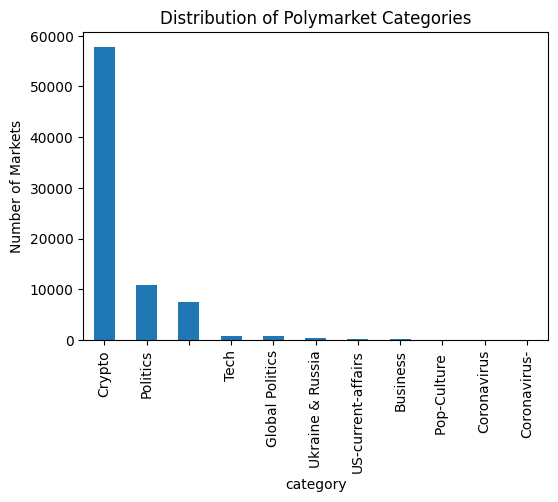

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

markets_df['category'].value_counts().plot(kind='bar')

plt.title("Distribution of Polymarket Categories")
plt.ylabel("Number of Markets")

plt.show()

In [13]:
# Prepare BTC returns
btc_returns = btc_df[['time','date','log_return']].dropna()

btc_returns.head()

,time,date,log_return
562,2010-07-19,2010-07-19,-0.060508
563,2010-07-20,2010-07-20,-0.078019
564,2010-07-21,2010-07-21,0.057928
565,2010-07-22,2010-07-22,-0.303376
566,2010-07-23,2010-07-23,0.035668


In [14]:
# Merge election markets with trades

election_trades = trades_df.merge(
    election_markets[['market_id','question']],
    on='market_id',
    how='inner'
)

election_trades = election_trades.merge(
    btc_df[['date','log_return']],
    on='date',
    how='left'
)

print("Election related trades:", len(election_trades))

election_trades.head()



Election related trades: 2541045


,trade_id,market_id,timestamp,price,size,side,date,question,log_return
0,0xaedcbe477774eef9ecce1e7bdd9700b277ef2e129f5a...,523604,2025-04-09 02:07:11,0.987,14.0,BUY,2025-04-09,Will Tulsi Gabbard be out as Director of Natio...,0.080122
1,0xaedcbe477774eef9ecce1e7bdd9700b277ef2e129f5a...,523604,2025-04-09 02:07:11,0.987,14.0,BUY,2025-04-09,Will Tulsi Gabbard be out as Director of Natio...,0.080122
2,0xaedcbe477774eef9ecce1e7bdd9700b277ef2e129f5a...,523604,2025-04-09 02:07:11,0.987,14.0,BUY,2025-04-09,Will Tulsi Gabbard be out as Director of Natio...,0.080122
3,0xaedcbe477774eef9ecce1e7bdd9700b277ef2e129f5a...,523604,2025-04-09 02:07:11,0.987,15.0,BUY,2025-04-09,Will Tulsi Gabbard be out as Director of Natio...,0.080122
4,0xaedcbe477774eef9ecce1e7bdd9700b277ef2e129f5a...,523604,2025-04-09 02:07:11,0.987,15.0,BUY,2025-04-09,Will Tulsi Gabbard be out as Director of Natio...,0.080122


### Part 2

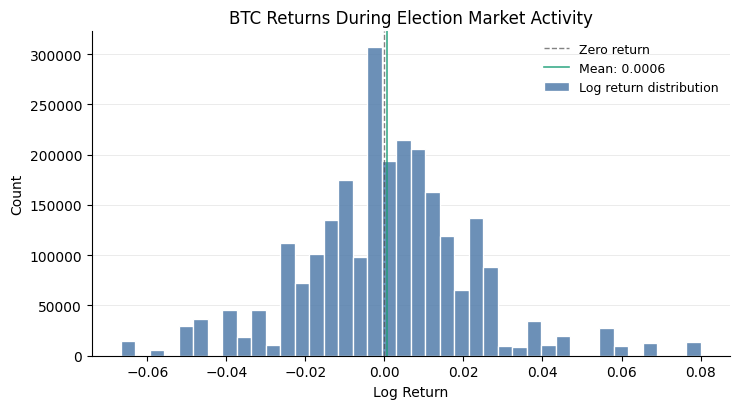

In [15]:
# Clean, minimal distribution of BTC log returns during election-market activity
returns = election_trades['log_return'].dropna()

fig, ax = plt.subplots(figsize=(7.5, 4.2))

sns.histplot(
    returns,
    bins=40,
    color='#4C78A8',
    edgecolor='white',
    alpha=0.82,
    label='Log return distribution',
    ax=ax
)

# Reference lines
ax.axvline(0, color='#4D4D4D', lw=1, ls='--', alpha=0.7, label='Zero return')
mean_val = returns.mean()
ax.axvline(mean_val, color='#1B9E77', lw=1.2, alpha=0.85, label=f"Mean: {mean_val:.4f}")

# Subtle grid and styling
ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.set_title("BTC Returns During Election Market Activity", fontsize=12)
ax.set_xlabel("Log Return")
ax.set_ylabel("Count")

ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


This histogram shows the distribution of Bitcoin returns during periods when election-related markets are actively traded.

If election events influence crypto markets, we may observe wider dispersion or heavier tails in returns.

However, if the distribution resembles the overall BTC return distribution, it suggests limited direct impact.

In [16]:
# Detect country mentioned in question text

country_keywords = {
    'US': 'us|usa|united states|trump|biden|senate|congress',
    'UK': 'uk|britain|london|prime minister',
    'France': 'france|macron',
    'Germany': 'germany',
    'India': 'india|modi',
    'China': 'china|xi'
}

def detect_country(text):

    text = str(text).lower()

    for country, pattern in country_keywords.items():
        if pd.Series(text).str.contains(pattern, regex=True).iloc[0]:
            return country

    return "Other"

election_markets['country'] = election_markets['question'].apply(detect_country)

election_markets['country'].value_counts()

country
US        7348
Other     3485
UK          30
China       28
India       10
France       8
Name: count, dtype: int64

In [17]:
# merge trades with election markets

election_trades_country = trades_df.merge(
    election_markets[['market_id','country']],
    on='market_id',
    how='inner'
)

election_trades_country['timestamp'] = pd.to_datetime(election_trades_country['timestamp'])

election_trades_country = election_trades_country.merge(
    btc_returns,
    on='date',
    how='left'
)


There is no market for India in trades_df!

C:\Users\19741\AppData\Local\Temp\ipykernel_14168\3111495471.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


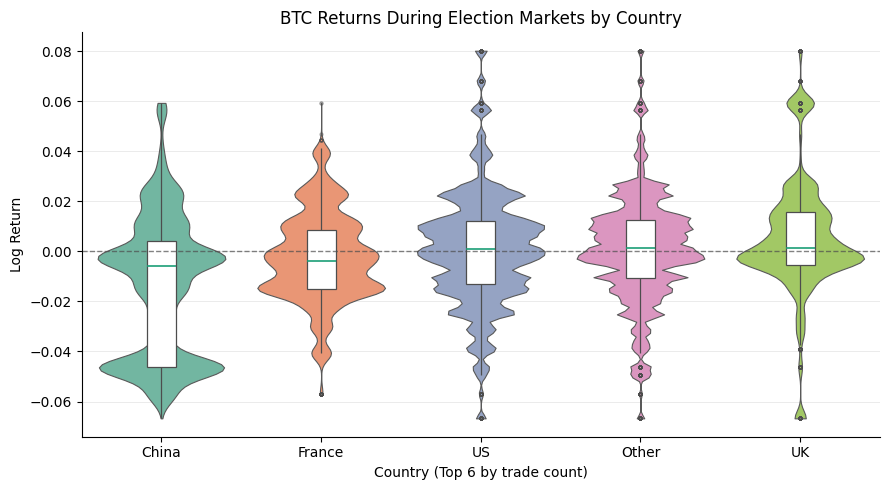

In [18]:
# Slightly more polished: violin + light box for top countries
df = election_trades_country[['country', 'log_return']].dropna()

top_n = 6
top_countries = df['country'].value_counts().head(top_n).index
plot_df = df[df['country'].isin(top_countries)].copy()

# Order by median return for clearer comparison
order = (
    plot_df.groupby('country')['log_return']
    .median()
    .sort_values()
    .index
)

fig, ax = plt.subplots(figsize=(9, 5))

sns.violinplot(
    data=plot_df,
    x='country',
    y='log_return',
    order=order,
    palette='Set2',
    inner=None,
    cut=0,
    linewidth=0.8,
    ax=ax
)

sns.boxplot(
    data=plot_df,
    x='country',
    y='log_return',
    order=order,
    width=0.18,
    showcaps=False,
    boxprops={'facecolor': 'white', 'edgecolor': '#4D4D4D', 'linewidth': 0.9},
    whiskerprops={'color': '#4D4D4D', 'linewidth': 0.9},
    medianprops={'color': '#1B9E77', 'linewidth': 1.2},
    flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.25, 'markeredgecolor': '#4D4D4D'},
    ax=ax
)

ax.axhline(0, color='#4D4D4D', lw=1, ls='--', alpha=0.7)

ax.set_title("BTC Returns During Election Markets by Country", fontsize=12)
ax.set_xlabel(f"Country (Top {top_n} by trade count)")
ax.set_ylabel("Log Return")

ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

sns.despine()
plt.tight_layout()
plt.show()


This violin plot compares the distribution of Bitcoin returns across election markets in different countries.

Several key patterns emerge:

- The US shows the widest distribution, indicating the highest volatility. This suggests that US elections have the strongest association with BTC price movements.

- The UK exhibits a slightly positive median return, implying that election-related activity may coincide with positive BTC performance.

- China displays a more negative skew, suggesting that election-related events may be associated with downward pressure on BTC prices.

- France and other regions show more neutral distributions, indicating weaker or less consistent effects.

Overall, the results suggest that the impact of election markets on Bitcoin is not uniform across countries, with US events playing a dominant role.

In [19]:
event_windows = []
    
for market_id, group in election_trades_country.groupby('market_id'):

    group = group.sort_values('timestamp')

    if len(group) < 7:
        continue

    window = group.tail(7)

    event_windows.append(window)

event_window_df = pd.concat(event_windows)

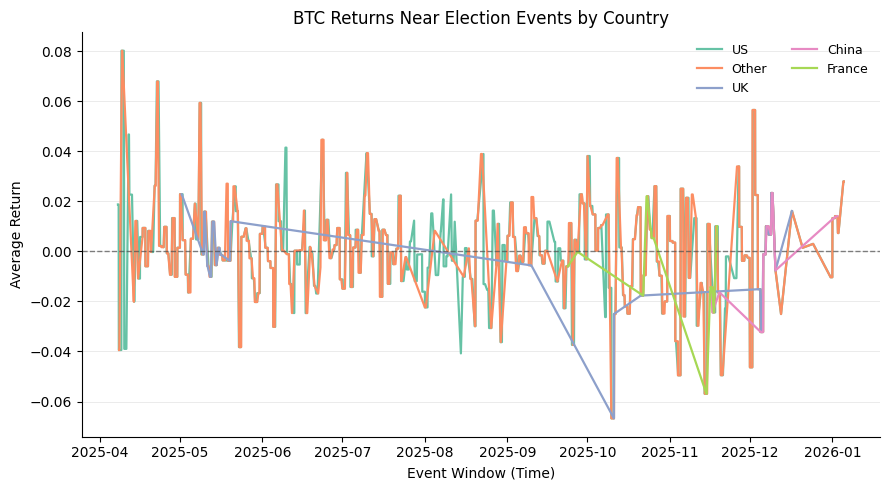

In [20]:
# Polished multi-line: average BTC returns near election events by country
top_n = 6

top_countries = (
    event_window_df['country']
    .value_counts()
    .head(top_n)
    .index
)

plot_df = event_window_df[event_window_df['country'].isin(top_countries)].copy()

fig, ax = plt.subplots(figsize=(9, 5))

palette = sns.color_palette("Set2", n_colors=top_n)

for color, country in zip(palette, top_countries):
    subset = plot_df[plot_df['country'] == country]
    avg_returns = subset.groupby('timestamp')['log_return'].mean()
    ax.plot(
        avg_returns.index,
        avg_returns.values,
        color=color,
        lw=1.6,
        label=country
    )

# Reference line and styling
ax.axhline(0, color='#4D4D4D', lw=1, ls='--', alpha=0.7)

ax.set_title("BTC Returns Near Election Events by Country", fontsize=12)
ax.set_xlabel("Event Window (Time)")
ax.set_ylabel("Average Return")

ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.legend(frameon=False, fontsize=9, ncol=2)
sns.despine()
plt.tight_layout()
plt.show()


In [21]:
event_windows = []

for market_id, group in election_trades_country.groupby('market_id'):

    group = group.sort_values('timestamp')

    # Only keep market with enough trade history
    if len(group) < 7:
        continue

    window = group.tail(7).copy()

    # Create event time
    window['event_time'] = range(-6, 1)

    event_windows.append(window)

event_window_df = pd.concat(event_windows)

avg_returns = (
    event_window_df
    .groupby(['country','event_time'])['log_return']
    .mean()
    .reset_index()
)

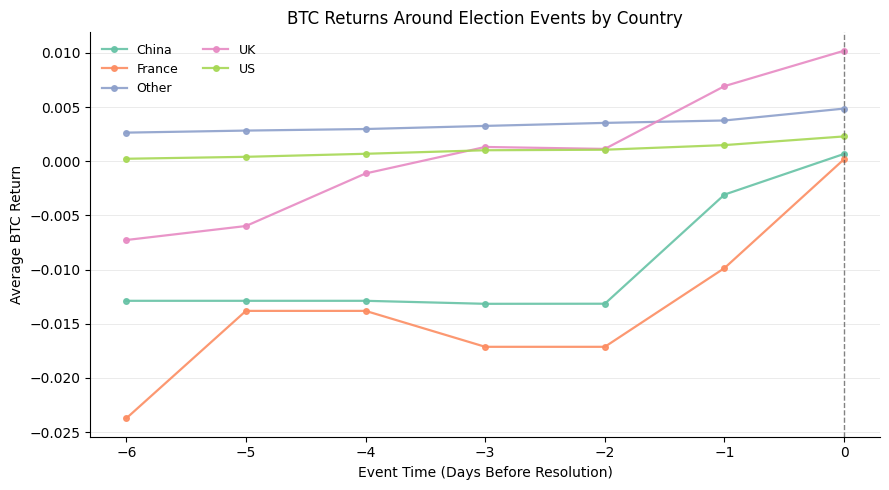

In [22]:
# Polished line chart: BTC returns around election events by country
top_n = 6
top_countries = (
    avg_returns['country']
    .value_counts()
    .head(top_n)
    .index
)

plot_df = avg_returns[avg_returns['country'].isin(top_countries)].copy()

fig, ax = plt.subplots(figsize=(9, 5))

palette = sns.color_palette("Set2", n_colors=top_n)

for color, country in zip(palette, top_countries):
    subset = plot_df[plot_df['country'] == country].sort_values('event_time')
    ax.plot(
        subset['event_time'],
        subset['log_return'],
        color=color,
        lw=1.6,
        marker='o',
        ms=4,
        alpha=0.9,
        label=country
    )

# Reference line at event day
ax.axvline(0, linestyle='--', color='#4D4D4D', lw=1, alpha=0.7)

# Subtle grid and styling
ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.set_xlabel("Event Time (Days Before Resolution)")
ax.set_ylabel("Average BTC Return")
ax.set_title("BTC Returns Around Election Events by Country", fontsize=12)

ax.legend(frameon=False, fontsize=9, ncol=2)
sns.despine()
plt.tight_layout()
plt.show()


This figure presents an event study of Bitcoin returns aligned around election market resolution.

Several key patterns emerge:

- Across most countries, BTC returns increase as the event approaches, particularly in the final two days before resolution. This suggests that markets may anticipate election outcomes.

- The UK shows the strongest upward trend, indicating a consistent increase in BTC returns leading up to the event.

- The US exhibits a more stable and gradual increase, suggesting a steady incorporation of information.

- China shows a delayed reaction, with returns remaining negative until a sharp increase just before the event.

- France displays a reversal pattern, with early negative returns followed by a late recovery.

Overall, these results suggest that election-related information may be incorporated into BTC prices in a gradual and country-dependent manner. However, the magnitude of these effects is relatively small, and the patterns may be influenced by underlying BTC market trends rather than election-specific factors.

In [23]:
election_odds = odds_history_df.merge(
    election_markets[['market_id','country']],
    on='market_id',
    how='inner'
)

election_odds = election_odds.merge(
    btc_returns,
    on='date',
    how='left'
)

d:\Anaconda\envs\tf\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


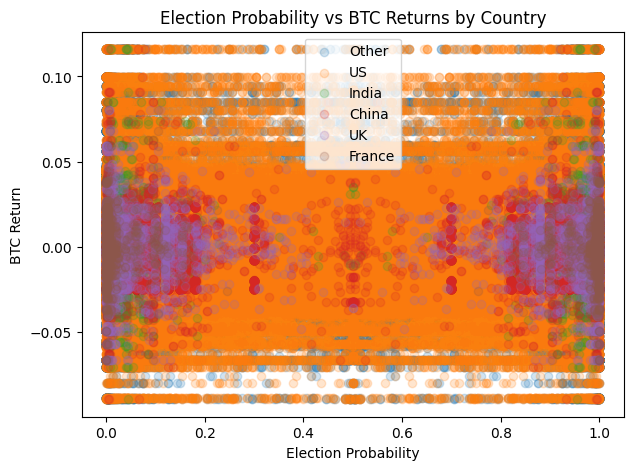

In [24]:
plt.figure(figsize=(7,5))

for country in election_odds['country'].unique():

    subset = election_odds[
        election_odds['country'] == country
    ]

    plt.scatter(
        subset['price'],
        subset['log_return'],
        alpha=0.2,
        label=country
    )
    

plt.legend()

plt.xlabel("Election Probability")

plt.ylabel("BTC Return")

plt.title("Election Probability vs BTC Returns by Country")

plt.show()

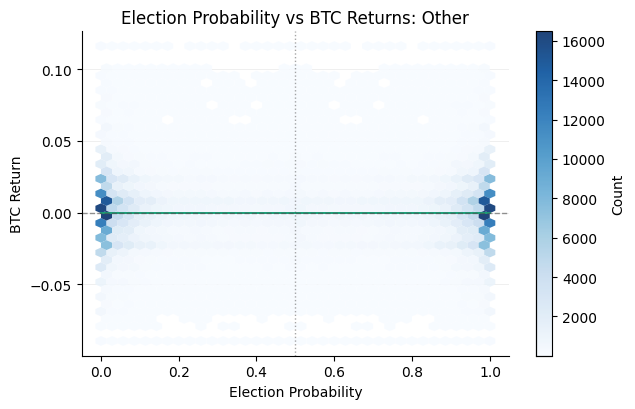

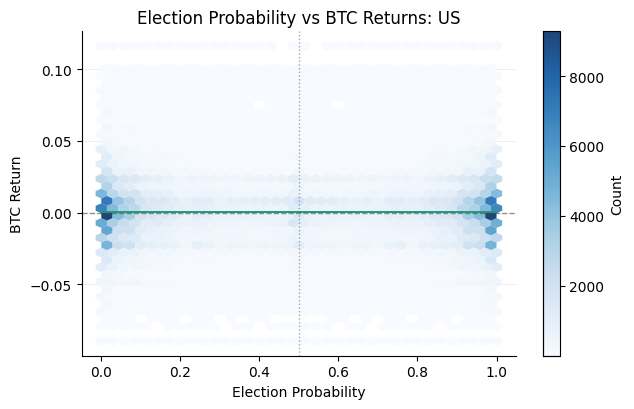

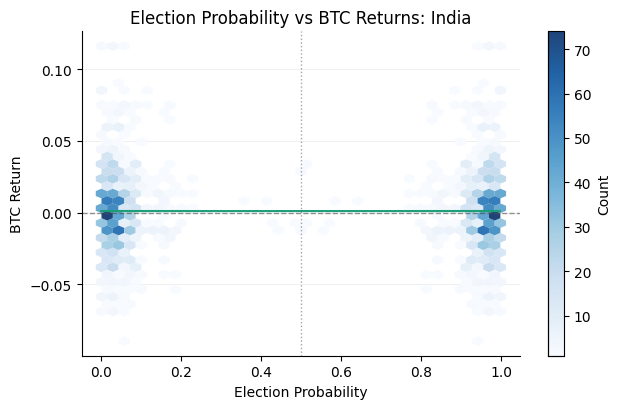

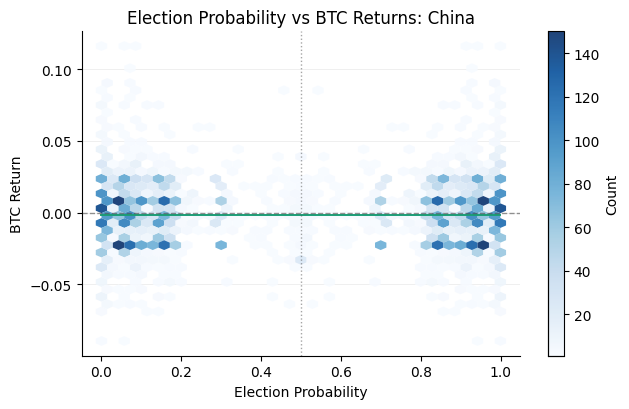

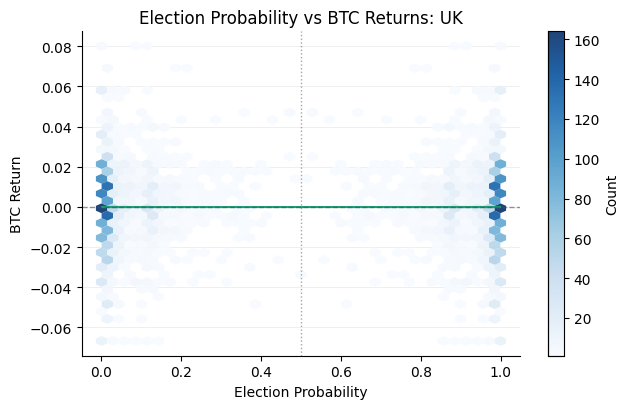

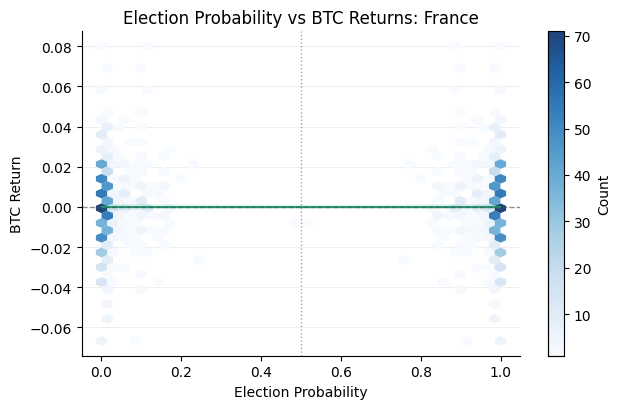

In [25]:
# Density-style: hexbin + regression line
countries = election_odds['country'].dropna().unique()

for country in countries:
    subset = election_odds[election_odds['country'] == country].dropna(subset=['price', 'log_return'])
    if subset.empty:
        continue

    fig, ax = plt.subplots(figsize=(6.5, 4.2))

    hb = ax.hexbin(
        subset['price'],
        subset['log_return'],
        gridsize=35,
        cmap='Blues',
        mincnt=1,
        linewidths=0,
        alpha=0.9
    )

    # Optional regression line (thin)
    sns.regplot(
        data=subset,
        x='price',
        y='log_return',
        scatter=False,
        line_kws={'color': '#1B9E77', 'lw': 1.4},
        ax=ax
    )

    ax.axhline(0, color='#4D4D4D', lw=1, ls='--', alpha=0.6)
    ax.axvline(0.5, color='#4D4D4D', lw=1, ls=':', alpha=0.5)

    ax.set_title(f"Election Probability vs BTC Returns: {country}", fontsize=12)
    ax.set_xlabel("Election Probability")
    ax.set_ylabel("BTC Return")

    cb = fig.colorbar(hb, ax=ax)
    cb.set_label("Count")

    ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.5)
    ax.set_axisbelow(True)

    sns.despine()
    plt.tight_layout()
    plt.show()


This hexbin density plot examines the relationship between prediction market probabilities and Bitcoin returns.

Election probability: The price of YES token of each market for each day.

Several key observations emerge:

- The distribution is heavily concentrated near probabilities of 0 and 1, indicating that prediction markets are often highly confident about outcomes.

- The regression line is nearly flat, suggesting no strong linear relationship between election probabilities and BTC returns.

- BTC returns exhibit high dispersion across all probability levels, indicating a noisy relationship.

Importantly, similar patterns are observed across all countries, suggesting that this result is not country-specific.

Overall, these findings indicate that prediction market probabilities alone have limited explanatory power for Bitcoin price movements.

### Part 3

In [26]:
geo_markets = markets_df[
    markets_df['category'].isin([
        'Ukraine & Russia',
        'Global Politics'
    ])
].copy()

print("Geopolitical markets:", len(geo_markets))

Geopolitical markets: 987


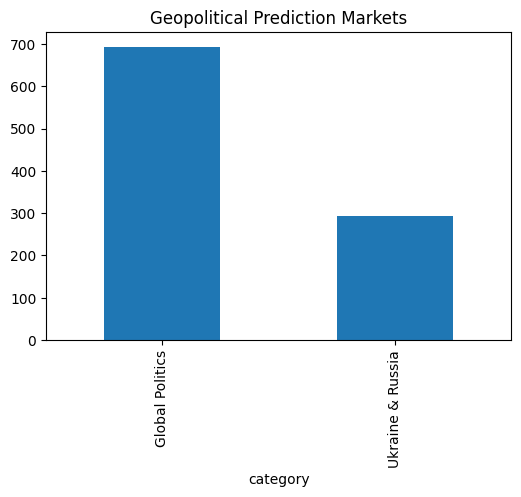

In [27]:
geo_markets['category'].value_counts().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Geopolitical Prediction Markets")

plt.show()

In [28]:
geo_trades = trades_df.merge(
    geo_markets[['market_id','question','category']],
    on='market_id',
    how='inner'
)

# Convert timestamp
geo_trades["timestamp"] = pd.to_datetime(geo_trades["timestamp"])

# Extract date
geo_trades["date"] = geo_trades["timestamp"].dt.date

# BTC date
btc_df["date"] = btc_df["time"].dt.date

# Merge
geo_trades = geo_trades.merge(
    btc_df[["date","log_return"]],
    on="date",
    how="left"
)

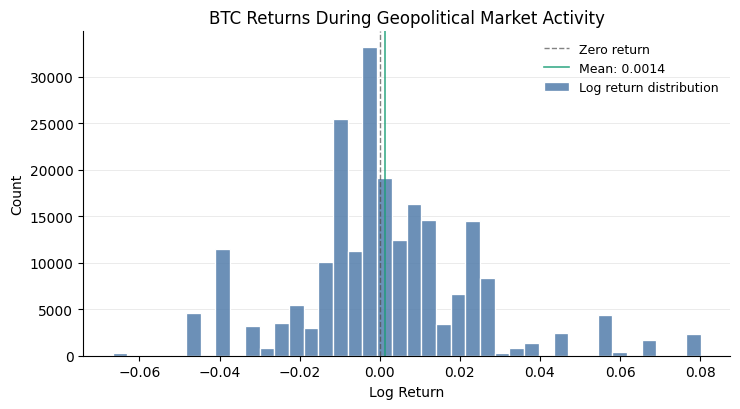

In [29]:
# Clean, minimal distribution of BTC log returns during geopolitical-market activity
geo_returns = geo_trades['log_return'].dropna()

fig, ax = plt.subplots(figsize=(7.5, 4.2))

sns.histplot(
    geo_returns,
    bins=40,
    color='#4C78A8',
    edgecolor='white',
    alpha=0.82,
    label='Log return distribution',
    ax=ax
)

# Reference lines
ax.axvline(0, color='#4D4D4D', lw=1, ls='--', alpha=0.7, label='Zero return')
mean_val = geo_returns.mean()
ax.axvline(mean_val, color='#1B9E77', lw=1.2, alpha=0.85, label=f"Mean: {mean_val:.4f}")

# Subtle grid and styling
ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.set_title("BTC Returns During Geopolitical Market Activity", fontsize=12)
ax.set_xlabel("Log Return")
ax.set_ylabel("Count")

ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


This histogram shows the distribution of Bitcoin returns during periods of geopolitical market activity.

The mean return is slightly positive (approximately 0.0014), suggesting a weak upward bias. However, the distribution is centered close to zero, indicating no strong directional effect.

The distribution exhibits relatively fat tails on both sides, implying that extreme positive and negative returns are more likely during these periods.

Overall, the results suggest that geopolitical events are more strongly associated with increased volatility rather than consistent price direction in Bitcoin.

This indicates that geopolitical events may act as sources of uncertainty, leading to wider return dispersion rather than predictable price movements.

In [30]:
event_windows = []

for market_id, group in geo_trades.groupby('market_id'):

    group = group.sort_values('timestamp')

    if len(group) < 5:
        continue

    window = group.tail(5)

    event_windows.append(window)

event_window_df = pd.concat(event_windows)

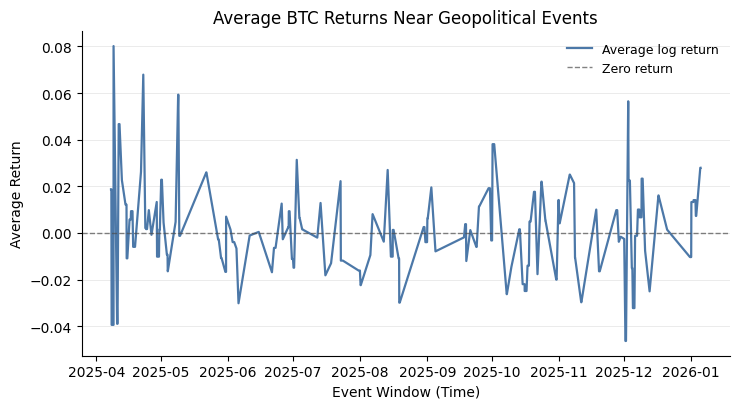

In [31]:
# Clean, minimal time series of average returns around geopolitical events
avg_returns = event_window_df.groupby('timestamp')['log_return'].mean()

fig, ax = plt.subplots(figsize=(7.5, 4.2))

ax.plot(
    avg_returns.index,
    avg_returns.values,
    color='#4C78A8',
    lw=1.6,
    label='Average log return'
)

# Reference lines
ax.axhline(0, color='#4D4D4D', lw=1, ls='--', alpha=0.7, label='Zero return')

# Subtle grid and styling
ax.grid(axis='y', color='#D9D9D9', lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.set_title("Average BTC Returns Near Geopolitical Events", fontsize=12)
ax.set_xlabel("Event Window (Time)")
ax.set_ylabel("Average Return")

ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


In [32]:
# Merge odds history with geopolitical markets

geo_odds = odds_history_df.merge(
    geo_markets[['market_id','question','category']],
    on='market_id',
    how='inner'
)

print("geo odds rows:", len(geo_odds))
geo_odds.head()

geo_odds["date"] = geo_odds["timestamp"].dt.date

geo_odds = geo_odds.merge(
    btc_df[["date","log_return"]],
    on="date",
    how="left"
)

geo_odds["uncertainty"] = abs(geo_odds["price"] - 0.5)

geo odds rows: 56453


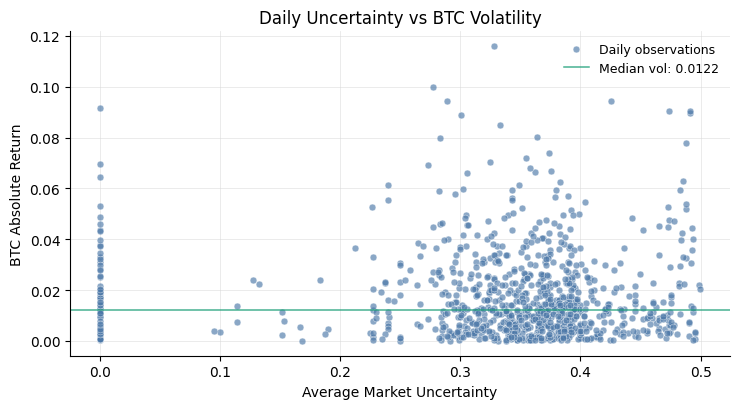

In [33]:
# Clean, minimal scatter: daily uncertainty vs BTC volatility
daily_geo = geo_odds.groupby("date").agg({
    "uncertainty": "mean",
    "log_return": "mean"
}).reset_index()

fig, ax = plt.subplots(figsize=(7.5, 4.2))

ax.scatter(
    daily_geo["uncertainty"],
    daily_geo["log_return"].abs(),
    s=24,
    color="#4C78A8",
    alpha=0.65,
    edgecolor="white",
    linewidth=0.4,
    label="Daily observations"
)

# Optional reference line at median volatility
med_vol = daily_geo["log_return"].abs().median()
ax.axhline(med_vol, color="#1B9E77", lw=1.1, alpha=0.8, label=f"Median vol: {med_vol:.4f}")

# Subtle grid and styling
ax.grid(color="#D9D9D9", lw=0.6, alpha=0.6)
ax.set_axisbelow(True)

ax.set_title("Daily Uncertainty vs BTC Volatility", fontsize=12)
ax.set_xlabel("Average Market Uncertainty")
ax.set_ylabel("BTC Absolute Return")

ax.legend(frameon=False, fontsize=9)
sns.despine()
plt.tight_layout()
plt.show()


We define uncertainty using the standard Bernoulli variance formula:

uncertainty = p × (1 − p)

where p is the market-implied probability.

This measure captures how uncertain the market is about the outcome:

- Uncertainty is highest when p ≈ 0.5  
- Uncertainty is lowest when p ≈ 0 or 1  

This provides a natural way to quantify disagreement or lack of consensus among market participants.

This scatter plot examines whether higher prediction market uncertainty is associated with larger Bitcoin price movements.

Uncertainty is highest when probabilities are close to 0.5.

If political uncertainty drives market volatility, we expect a positive relationship between uncertainty and absolute BTC returns.

In [34]:
# =========================================================
# Transformer-based Bitcoin Price Forecast (Auto-Adaptive)
# =========================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from datetime import timedelta

# Torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# -----------------------------
# 1) Fancy plot styling
# -----------------------------
def apply_fancy_style():
    sns.set_theme(style="whitegrid")
    plt.rcParams.update({
        "figure.facecolor": "#F5F7FA",
        "axes.facecolor": "#FFFFFF",
        "axes.edgecolor": "#222222",
        "grid.color": "#E2E8F0",
        "grid.linestyle": "-",
        "grid.linewidth": 0.8,
        "axes.titleweight": "bold",
        "axes.titlecolor": "#1F2937",
        "axes.labelcolor": "#374151",
        "xtick.color": "#374151",
        "ytick.color": "#374151",
        "font.size": 11
    })

apply_fancy_style()

# -----------------------------
# 2) Defensive conversions
# -----------------------------
if "btc_df" not in globals():
    raise ValueError("btc_df not found. Please run the EDA cells first.")

# Ensure pandas DataFrame
if not isinstance(btc_df, pd.DataFrame):
    btc_df = btc_df.to_pandas()

btc_df = btc_df.copy()
btc_df["time"] = pd.to_datetime(btc_df["time"])
btc_df["date"] = btc_df["time"].dt.date

# -----------------------------
# 3) Polymarket feature builder
# -----------------------------
def detect_country(text):
    country_keywords = {
        'US': 'us|usa|united states|trump|biden|senate|congress',
        'UK': 'uk|britain|london|prime minister',
        'France': 'france|macron',
        'Germany': 'germany',
        'India': 'india|modi',
        'China': 'china|xi'
    }
    text = str(text).lower()
    for country, pattern in country_keywords.items():
        if pd.Series(text).str.contains(pattern, regex=True).iloc[0]:
            return country
    return "Other"

def build_polymarket_features(markets_df, odds_history_df, trades_df):
    # Copy and normalize timestamps
    m = markets_df.copy()
    o = odds_history_df.copy()
    t = trades_df.copy()

    for df, col in [(o, "timestamp"), (t, "timestamp")]:
        if pd.api.types.is_datetime64_any_dtype(df[col]):
            if df[col].dt.year.eq(1970).all():
                df[col] = pd.to_datetime(df[col].astype("int64"), unit="ms", errors="coerce")
        else:
            df[col] = pd.to_datetime(df[col], unit="ms", errors="coerce")

    o["date"] = o["timestamp"].dt.date
    t["date"] = t["timestamp"].dt.date

    # Add country for politics
    m["country"] = m["question"].apply(detect_country)

    # -------------------
    # Odds-derived features
    # -------------------
    odds = o.merge(m[["market_id", "category", "country"]], on="market_id", how="left")
    odds["uncertainty"] = odds["price"] * (1 - odds["price"])

    daily_base = odds.groupby("date").agg(
        pm_price_mean=("price", "mean"),
        pm_price_std=("price", "std"),
        pm_uncertainty_mean=("uncertainty", "mean"),
        pm_obs=("price", "count")
    ).reset_index()

    # Category-specific aggregates (only if present)
    cat_features = []
    for cat in ["Politics", "Ukraine & Russia", "Global Politics", "Crypto"]:
        if cat in odds["category"].dropna().unique():
            tmp = odds[odds["category"] == cat].groupby("date").agg(
                price_mean=("price", "mean"),
                uncertainty_mean=("uncertainty", "mean"),
                obs=("price", "count")
            )
            tmp.columns = [f"pm_{cat.lower().replace(' ', '_').replace('&','and')}_{c}" for c in tmp.columns]
            tmp = tmp.reset_index()
            cat_features.append(tmp)

    # Country-specific aggregates for Politics (top 4)
    pol = odds[odds["category"] == "Politics"].copy()
    top_countries = pol["country"].value_counts().head(4).index.tolist()
    country_features = []
    for c in top_countries:
        tmp = pol[pol["country"] == c].groupby("date").agg(
            price_mean=("price", "mean"),
            uncertainty_mean=("uncertainty", "mean"),
            obs=("price", "count")
        )
        tmp.columns = [f"pm_country_{c.lower()}_{col}" for col in tmp.columns]
        tmp = tmp.reset_index()
        country_features.append(tmp)

    # -------------------
    # Trades-derived features
    # -------------------
    trades = t.merge(m[["market_id", "category", "country"]], on="market_id", how="left")
    trades["is_buy"] = trades["side"].astype(str).str.lower().str.contains("buy").astype(int)

    daily_trades = trades.groupby("date").agg(
        pm_trade_count=("trade_id", "count"),
        pm_trade_size_sum=("size", "sum"),
        pm_trade_size_mean=("size", "mean"),
        pm_buy_ratio=("is_buy", "mean")
    ).reset_index()

    # Merge all Polymarket daily features
    feat = daily_base.merge(daily_trades, on="date", how="outer")
    for df in cat_features + country_features:
        feat = feat.merge(df, on="date", how="outer")

    return feat

# -----------------------------
# 4) Build dataset
# -----------------------------
if not all(x in globals() for x in ["markets_df", "odds_history_df", "trades_df"]):
    raise ValueError("Missing Polymarket dataframes. Please run the EDA cells first.")

pm_feat = build_polymarket_features(markets_df, odds_history_df, trades_df)

# CoinMetrics features
coin = btc_df.copy()
coin = coin.sort_values("date")

# Keep only valid positive BTC prices
coin["PriceUSD"] = pd.to_numeric(coin["PriceUSD"], errors="coerce")
coin = coin.replace([np.inf, -np.inf], np.nan)
coin = coin.dropna(subset=["PriceUSD"])
coin = coin[coin["PriceUSD"] > 0].copy()

coin_cols = coin.select_dtypes(include=[np.number]).columns.tolist()

target_col = "PriceUSD"
if target_col not in coin_cols:
    raise ValueError("PriceUSD not found in btc_df numeric columns.")

# Merge Polymarket features
data = coin.merge(pm_feat, on="date", how="left")
data = data.sort_values("date")

# Basic cleaning
data = data.replace([np.inf, -np.inf], np.nan)
data = data.ffill().fillna(0)

# Build target: next-day BTC log return, not next-day price level
data["log_price"] = np.log(data[target_col].replace(0, np.nan))
data["target"] = data["log_price"].shift(-1) - data["log_price"]

data = data.replace([np.inf, -np.inf], np.nan)
data = data.dropna(subset=["target"]).reset_index(drop=True)

print("Target summary: next-day log return")
print(data["target"].describe())

# -----------------------------
# 5) Feature selection
# -----------------------------
# Candidate CoinMetrics features: numeric columns except raw price and target helpers
exclude_cols = {
    target_col,
    "target",
    "log_price",
}

candidate_coin_cols = [
    c for c in coin_cols
    if c not in exclude_cols and c in data.columns
]

# Clean correlation input
corr_data = data[candidate_coin_cols + ["target"]].replace(
    [np.inf, -np.inf],
    np.nan
)

corr_data = corr_data.dropna(subset=["target"])

# Drop columns with no variation, because correlation is undefined
valid_candidate_cols = [
    c for c in candidate_coin_cols
    if corr_data[c].notna().sum() > 2 and corr_data[c].std(skipna=True) > 0
]

corrs = (
    corr_data[valid_candidate_cols]
    .corrwith(corr_data["target"])
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .abs()
    .sort_values(ascending=False)
)

top_k = 10
selected_coin = corrs.head(top_k).index.tolist()

# Always include Polymarket features
pm_cols = [c for c in data.columns if c.startswith("pm_")]

# Final feature set
feature_cols = selected_coin + pm_cols
feature_cols = list(dict.fromkeys(feature_cols))

print(f"Selected CoinMetrics features (top {top_k}): {selected_coin}")
print(f"Polymarket features: {len(pm_cols)} columns")
print(f"Total features: {len(feature_cols)}")

if len(feature_cols) == 0:
    raise ValueError("No valid feature columns found.")

# -----------------------------
# 6) Sequence dataset
# -----------------------------
LOOKBACK = 30

class SeqDataset(Dataset):
    def __init__(self, X, y, lookback):
        self.X = X
        self.y = y
        self.lookback = lookback

    def __len__(self):
        return len(self.X) - self.lookback

    def __getitem__(self, idx):
        x_seq = self.X[idx:idx + self.lookback]
        y_t = self.y[idx + self.lookback - 1]

        return (
            torch.tensor(x_seq, dtype=torch.float32),
            torch.tensor(y_t, dtype=torch.float32)
        )

# Split by time
n = len(data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = data.iloc[:train_end].copy()
val_df = data.iloc[train_end:val_end].copy()
test_df = data.iloc[val_end:].copy()

# Scale features using train only
x_scaler = StandardScaler()

X_train = x_scaler.fit_transform(train_df[feature_cols])
X_val = x_scaler.transform(val_df[feature_cols])
X_test = x_scaler.transform(test_df[feature_cols])

# Scale target using train only
y_scaler = StandardScaler()

y_train = y_scaler.fit_transform(train_df[["target"]]).ravel()
y_val = y_scaler.transform(val_df[["target"]]).ravel()
y_test = y_scaler.transform(test_df[["target"]]).ravel()

train_ds = SeqDataset(X_train, y_train, LOOKBACK)
val_ds = SeqDataset(X_val, y_val, LOOKBACK)
test_ds = SeqDataset(X_test, y_test, LOOKBACK)

train_loader = DataLoader(
    train_ds,
    batch_size=64,
    shuffle=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=64,
    shuffle=False
)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False
)

print(f"Train sequences: {len(train_ds):,}")
print(f"Validation sequences: {len(val_ds):,}")
print(f"Test sequences: {len(test_ds):,}")
print(f"Target mean in train: {train_df['target'].mean():.6f}")
print(f"Target std in train: {train_df['target'].std():.6f}")

# -----------------------------
# 7) Transformer model
# -----------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(
            torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)

        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class TimeSeriesTransformer(nn.Module):
    def __init__(self, n_features, d_model=32, nhead=4, num_layers=2, dropout=0.15):
        super().__init__()

        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dropout=dropout,
            batch_first=True
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Linear(d_model, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1)
        )

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        out = self.head(x[:, -1, :])
        return out.squeeze(-1)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TimeSeriesTransformer(
    n_features=len(feature_cols),
    d_model=32,
    nhead=4,
    num_layers=2,
    dropout=0.15
).to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=5e-4,
    weight_decay=1e-4
)


Target summary: next-day log return
count    5658.000000
mean        0.002460
std         0.047273
min        -0.664948
25%        -0.012631
50%         0.001473
75%         0.018171
max         0.436655
Name: target, dtype: float64
Selected CoinMetrics features (top 10): ['ROI30d', 'BlkCnt', 'ROI1yr', 'IssTotNtv', 'SplyExpFut10yr', 'SplyCur', 'SplyExNtv', 'IssTotUSD', 'AdrBalCnt', 'TxTfrCnt']
Polymarket features: 32 columns
Total features: 42
Train sequences: 3,930
Validation sequences: 819
Test sequences: 819
Target mean in train: 0.003277
Target std in train: 0.053330


Next-day log return is the logarithm of next-day return rate:

next-day log return = log(P_{t+1} / P_t),

where P_t is BTC price at day t. 

If log return > 0, we predict the price will be higher than today;

if log return < 0, we predict the price will be lower than today.


In [35]:
# -----------------------------
# 8) Training loop with early stopping
# -----------------------------
best_val = float("inf")
best_state = None
patience = 10
pat_counter = 0
EPOCHS = 80

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []

    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()

        pred = model(xb)
        loss = criterion(pred, yb)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_losses.append(loss.item())

    model.eval()
    val_losses = []

    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            pred = model(xb)
            loss = criterion(pred, yb)

            val_losses.append(loss.item())

    train_loss = np.mean(train_losses)
    val_loss = np.mean(val_losses)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss (scaled): {train_loss:.6f} | "
        f"Val Loss (scaled): {val_loss:.6f}"
    )

    if val_loss < best_val:
        best_val = val_loss
        best_state = model.state_dict()
        pat_counter = 0
    else:
        pat_counter += 1

        if pat_counter >= patience:
            print("Early stopping triggered.")
            break

if best_state is not None:
    model.load_state_dict(best_state)

# -----------------------------
# 9) Evaluation
# -----------------------------
model.eval()

preds_scaled = []
actuals_scaled = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)

        pred = model(xb).cpu().numpy()

        preds_scaled.append(pred)
        actuals_scaled.append(yb.numpy())

preds_scaled = np.concatenate(preds_scaled)
actuals_scaled = np.concatenate(actuals_scaled)

# Convert predictions and actuals back to original log-return scale
preds = y_scaler.inverse_transform(
    preds_scaled.reshape(-1, 1)
).ravel()

actuals = y_scaler.inverse_transform(
    actuals_scaled.reshape(-1, 1)
).ravel()

mae = mean_absolute_error(actuals, preds)
rmse = np.sqrt(mean_squared_error(actuals, preds))
r2 = r2_score(actuals, preds)

directional_acc = (
    np.sign(actuals) == np.sign(preds)
).mean() * 100

# Naive baseline: always predict zero return
baseline_preds = np.zeros_like(actuals)

baseline_mae = mean_absolute_error(actuals, baseline_preds)
baseline_rmse = np.sqrt(mean_squared_error(actuals, baseline_preds))

# Directional baseline: always predict the majority direction in the test set
majority_direction = 1 if (actuals > 0).mean() >= 0.5 else -1
baseline_direction_preds = np.full_like(actuals, majority_direction)

baseline_directional_acc = (
    np.sign(actuals) == np.sign(baseline_direction_preds)
).mean() * 100

print("\nModel Performance on Test Set")
print("Target: next-day BTC log return")
print(f"MAE  : {mae:.6f}")
print(f"RMSE : {rmse:.6f}")
print(f"R^2  : {r2:.4f}")
print(f"Directional Accuracy: {directional_acc:.2f}%")

print("\nNaive Zero-Return Baseline")
print(f"MAE  : {baseline_mae:.6f}")
print(f"RMSE : {baseline_rmse:.6f}")

print("\nMajority-Direction Baseline")
print(f"Direction predicted: {'Up' if majority_direction == 1 else 'Down'}")
print(f"Directional Accuracy: {baseline_directional_acc:.2f}%")


Epoch 01 | Train Loss (scaled): 0.994792 | Val Loss (scaled): 0.348702
Epoch 02 | Train Loss (scaled): 0.980185 | Val Loss (scaled): 0.345043
Epoch 03 | Train Loss (scaled): 0.981642 | Val Loss (scaled): 0.357143
Epoch 04 | Train Loss (scaled): 0.996623 | Val Loss (scaled): 0.350265
Epoch 05 | Train Loss (scaled): 0.977789 | Val Loss (scaled): 0.357104
Epoch 06 | Train Loss (scaled): 0.974208 | Val Loss (scaled): 0.346591
Epoch 07 | Train Loss (scaled): 0.981201 | Val Loss (scaled): 0.351293
Epoch 08 | Train Loss (scaled): 0.969755 | Val Loss (scaled): 0.360061
Epoch 09 | Train Loss (scaled): 0.985019 | Val Loss (scaled): 0.345676
Epoch 10 | Train Loss (scaled): 0.974587 | Val Loss (scaled): 0.348118
Epoch 11 | Train Loss (scaled): 0.987216 | Val Loss (scaled): 0.353400
Epoch 12 | Train Loss (scaled): 0.972893 | Val Loss (scaled): 0.357985
Early stopping triggered.

Model Performance on Test Set
Target: next-day BTC log return
MAE  : 0.020029
RMSE : 0.026619
R^2  : -0.1745
Directional 

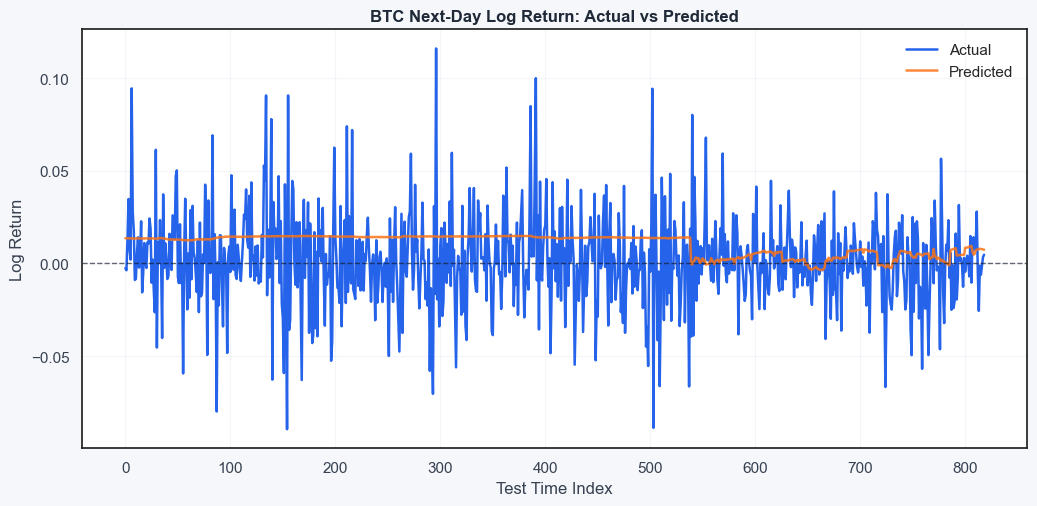

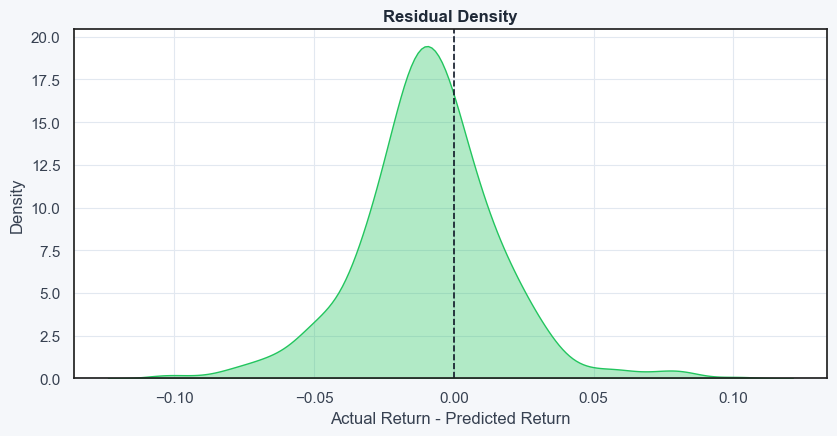

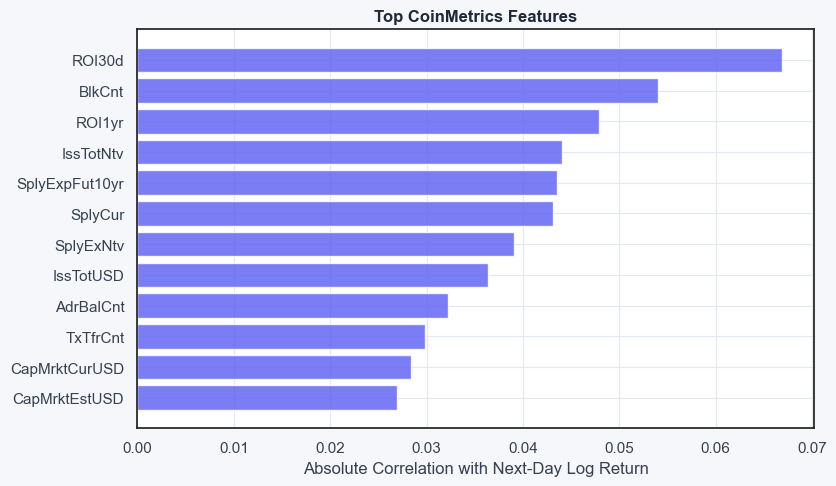


Model Summary (Transformer)
- Target: next-day BTC log return
- Target scaling: StandardScaler fitted on training target only
- Lookback window: 30 days
- Features: 42 (CoinMetrics top 10 + Polymarket aggregates)
- Test MAE: 0.020029
- Test RMSE: 0.026619
- R^2: -0.1745
- Directional Accuracy: 52.26%

Zero-Return Baseline
- MAE: 0.017668
- RMSE: 0.024603

Majority-Direction Baseline
- Direction predicted: Up
- Directional Accuracy: 52.63%

Interpretation:
1. The model trains on standardized next-day log returns, which makes the optimization problem more stable.
2. Predictions are inverse-transformed back to the original log-return scale before evaluation and plotting.
3. The zero-return baseline is useful for MAE/RMSE comparison.
4. The majority-direction baseline is more appropriate for directional accuracy comparison.



In [36]:
# -----------------------------
# 10) Results plots
# -----------------------------
apply_fancy_style()

# Actual vs predicted next-day log returns
fig, ax = plt.subplots(figsize=(10.5, 5.2))

ax.plot(actuals, label="Actual", lw=1.8, color="#2563EB")
ax.plot(preds, label="Predicted", lw=1.8, color="#F97316", alpha=0.85)

ax.axhline(0, color="#111827", lw=1, linestyle="--", alpha=0.65)

ax.set_title("BTC Next-Day Log Return: Actual vs Predicted")
ax.set_xlabel("Test Time Index")
ax.set_ylabel("Log Return")
ax.legend(frameon=False)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


# Residual distribution
residuals = actuals - preds

fig, ax = plt.subplots(figsize=(8.5, 4.5))

sns.kdeplot(residuals, fill=True, color="#22C55E", alpha=0.35, ax=ax)

ax.axvline(0, color="#111827", lw=1.2, linestyle="--")
ax.set_title("Residual Density")
ax.set_xlabel("Actual Return - Predicted Return")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()


# Feature correlation chart
top_corr = corrs.head(12).sort_values()

fig, ax = plt.subplots(figsize=(8.5, 5.0))

if top_corr.empty:
    ax.text(
        0.5,
        0.5,
        "No valid CoinMetrics correlations",
        ha="center",
        va="center",
        fontsize=12
    )
    ax.axis("off")
else:
    ax.barh(top_corr.index, top_corr.values, color="#6366F1", alpha=0.85)
    ax.set_title("Top CoinMetrics Features")
    ax.set_xlabel("Absolute Correlation with Next-Day Log Return")

plt.tight_layout()
plt.show()

# -----------------------------
# 11) Text summary
# -----------------------------
summary_text = f"""
Model Summary (Transformer)
- Target: next-day BTC log return
- Target scaling: StandardScaler fitted on training target only
- Lookback window: {LOOKBACK} days
- Features: {len(feature_cols)} (CoinMetrics top {top_k} + Polymarket aggregates)
- Test MAE: {mae:.6f}
- Test RMSE: {rmse:.6f}
- R^2: {r2:.4f}
- Directional Accuracy: {directional_acc:.2f}%

Zero-Return Baseline
- MAE: {baseline_mae:.6f}
- RMSE: {baseline_rmse:.6f}

Majority-Direction Baseline
- Direction predicted: {'Up' if majority_direction == 1 else 'Down'}
- Directional Accuracy: {baseline_directional_acc:.2f}%

Interpretation:
1. The model trains on standardized next-day log returns, which makes the optimization problem more stable.
2. Predictions are inverse-transformed back to the original log-return scale before evaluation and plotting.
3. The zero-return baseline is useful for MAE/RMSE comparison.
4. The majority-direction baseline is more appropriate for directional accuracy comparison.
"""

print(summary_text)

